In [155]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scienceplots
plt.style.use(['science','ieee'])

# Increase font sizes manually
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})
from numpy import mean, std
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



## Load data & select features

In [167]:
# df = pd.read_csv('../feature_engineering/data_for_temporal_model.csv')
df_raw = pd.read_csv("../../data_cleaning/data/imputed_data.csv")
df_raw.rename(columns={'person': 'participant'}, inplace=True)
df = pd.read_csv("../../non_temporal_predictions/feature_engineering/data_with_new_features_v3.csv")

In [67]:
import re

def select_feature_groups(df, group_names):
    base = ['timestamp', 'participant', 'genre']

    groups = {
        "raw": ['heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm', 'iris_diameter_mm', 'pupil_iris_ratio'],
        'head_movement':['head_displacement', 'head_velocity', 'head_direction_change_rate', 'head_stability', 'centered_x', 'centered_y'],
    }

    selected = set(base)
    for name in group_names:
        selected.update(groups.get(name, []))

    return df[list(selected)]

df = select_feature_groups(df, ['raw', 'head_movement'])

## Data preprocessing

In [ ]:
# Encode target variable (genre)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['genre'])
num_classes = len(label_encoder.classes_)

# Features to use
features = ['x_coordinate', 'heart_rate', 'pupil_diameter_mm', 'iris_diameter_mm',
       'centered_y', 'head_displacement', 'head_stability',
       'head_velocity', 'head_direction_change_rate',
       'pupil_iris_ratio', 'y_coordinate', 'centered_x']

# Normalize features with standardscaler
scaler = StandardScaler()
scaler.fit(df[features])

# Filter participants
train_df = df[df['participant'].isin(['kenji', 'aimen'])]
test_df = df[df['participant'] == 'clara']

# Original training features and labels
train_X_original = train_df[features]
train_y_original = train_df['label']
test_X_original = test_df[features]
test_y_original = test_df['label']


# Same steps for the raw df
df_raw['label'] = label_encoder.fit_transform(df_raw['genre'])
features = ['heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm','iris_diameter_mm', 'pupil_iris_ratio']
scaler.fit(df_raw[features])

train_df_raw = df_raw[df_raw['participant'].isin(['kenji', 'aimen'])]
test_df_raw = df_raw[df_raw['participant'] == 'clara']

train_X_original_raw = train_df_raw[features]
train_y_original_raw = train_df_raw['label']
test_X_original_raw = test_df_raw[features]
test_y_original_raw = test_df_raw['label']

In [69]:
train_X_original

,x_coordinate,heart_rate,pupil_diameter_mm,iris_diameter_mm,centered_y,head_displacement,head_stability,head_velocity,head_direction_change_rate,pupil_iris_ratio,y_coordinate,centered_x
0,409.206897,62.000000,2.602941,11.8,-49.945073,0.000000,0.000000,0.000000,0.000000,0.220588,194.000000,59.996531
1,413.433333,61.500000,2.602941,11.8,-49.145073,4.301484,1.777114,4.301484,0.000000,0.220588,194.800000,64.222968
2,397.333333,60.000000,2.602941,11.8,-52.945073,16.542370,5.175264,5.514123,3.096881,0.220588,191.000000,48.122968
3,397.166667,60.000000,2.602941,11.8,-53.345073,0.433333,5.207589,0.216667,2.020552,0.220588,190.600000,47.956301
4,391.000000,60.000000,2.602941,11.8,-54.611739,6.295413,5.834263,2.098471,1.671507,0.220588,189.333333,41.789635
...,...,...,...,...,...,...,...,...,...,...,...,...
9339,354.483871,69.555556,2.726626,11.8,76.935619,0.965066,0.576733,0.965066,1.437645,0.231070,323.258065,-36.095340
9340,354.600000,69.666667,2.726626,11.8,77.677555,0.750969,0.747580,0.750969,1.619565,0.231070,324.000000,-35.979211
9341,355.000000,69.777778,2.726626,11.8,77.608589,0.405902,0.805218,0.405902,1.425149,0.231070,323.931034,-35.579211
9342,355.500000,69.888889,2.726626,11.8,77.577555,0.500962,0.794631,0.500962,1.405554,0.231070,323.900000,-35.079211


## Build & Train Model

In [ ]:
# Create sequences with fixed window size
def create_sequences(data, labels, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(labels.iloc[i + window_size - 1])  # label at the end of the window
    return np.array(X), to_categorical(np.array(y), num_classes=num_classes)

# Fit and evaluate a model
def evaluate_model(X, y, X_test, y_test, window_size=10, epochs=15, batch_size=64, units=100, dropout_rate=0.5, dense_units=100, early_stopping_patience=10, verbose=2, learning_rate=5e-4):
    
    X_train, y_train = create_sequences(X, y, window_size)
    
    train_X, val_X, train_y, val_y = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
      
    verbose = verbose
    n_timesteps, n_features, n_outputs = train_X.shape[1], train_X.shape[2], train_y.shape[1]
    
    model = Sequential()
    model.add(Input(shape=(n_timesteps, n_features)))
    
    # model.add(LSTM(units, activation='relu'))
    # model.add(Dropout(dropout_rate))

    for i in range(3):
        # all but last need to return sequences
        return_seq = (i < 3 - 1)
        model.add(LSTM(units, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))
    
    
    model.add(Dense(dense_units, activation='softmax'))
    model.add(Dense(num_classes, activation='softmax'))  # final output layer
    
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=early_stopping_patience, restore_best_weights=True)

    # Train
    history = model.fit(train_X, train_y, epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=[early_stopping], validation_data=(val_X, val_y))
    
    # Evaluate
    test_X, test_y = create_sequences(X_test, y_test, window_size)
    preds = model.predict(test_X, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(test_y, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0)

    #print accuracy
    accuracy = np.mean(y_true == y_pred) * 100
    print(f'Accuracy: {accuracy:.2f}%')

    return history, cm, cr, accuracy

# Run experiment multiple times
def run_experiment(X, y, X_test, y_test, 
    window_size=10, epochs=15, batch_size=64, repeats=10,
    units=100, dropout_rate=0.5, dense_units=100,
    verbose=2, learning_rate=5e-4
):
    histories = []
    cms       = []
    reports   = []
    accuracies = []
    for r in range(repeats):
        print(f"\n--- Run #{r+1} ---")
        history, cm, cr, accuracy = evaluate_model(
            X, y, X_test, y_test, 
            window_size=window_size,
            epochs=epochs,
            batch_size=batch_size,
            units=units,
            dropout_rate=dropout_rate,
            dense_units=dense_units,
            verbose=verbose,
            learning_rate=learning_rate

        )
        histories.append(history)
        cms.append(cm)
        reports.append(cr)
        accuracies.append(accuracy)

    return histories, cms, reports, accuracies

In [94]:
def plot_metrics(histories):
    epochs = max(len(h.history['loss']) for h in histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy subplot
    for idx, history in enumerate(histories, 1):
        axes[0].plot(history.history['accuracy'], label=f'Train Acc', alpha=0.7)
        axes[0].plot(history.history['val_accuracy'], '--', label=f'Val Acc', alpha=0.7)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)

    # Loss subplot
    for idx, history in enumerate(histories, 1):
        axes[1].plot(history.history['loss'], label=f'Train Loss', alpha=0.7)
        axes[1].plot(history.history['val_loss'], '--', label=f'Val Loss', alpha=0.7)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## Hyperparameter Tuning

In [104]:
import optuna
import numpy as np
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

# assume create_sequences() is defined as before,
# and df, train_df, test_df, label_encoder, num_classes are in scope

best_model = None  # to store the best model found during tuning

def build_model(input_shape, 
                n_layers, 
                units, 
                dropout_rate, 
                dense_units, 
                learning_rate):
    m = Sequential()
    m.add(Input(shape=input_shape))
    # stack n_layers LSTMs
    for i in range(n_layers):
        # all but last need to return sequences
        return_seq = (i < n_layers - 1)
        m.add(LSTM(units, return_sequences=return_seq))
        m.add(Dropout(dropout_rate))
    m.add(Dense(dense_units, activation='relu'))
    m.add(Dense(num_classes, activation='softmax'))
    m.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return m

def objective(trial):
    global best_model  # to access the best model outside this function
    # 1) hyperparameter search space
    window_size  = trial.suggest_categorical('window_size',  [5, 10, 15, 20])
    n_layers     = trial.suggest_categorical('n_layers',     [1, 2, 3]) 
    units        = trial.suggest_categorical('units',        [4, 8, 16])
    dropout_rate = trial.suggest_categorical('dropout_rate', [0.3, 0.5, 0.7])
    dense_units  = trial.suggest_categorical('dense_units',  [2, 6, 10])
    lr           = trial.suggest_categorical('lr',           [5e-5, 5e-4, 5e-3])
    patience        = 5
    batch_size      = 32
    epochs          = 100  # will stop early

    # 2) build your train/val splits & scale
    X_train, y_train = create_sequences(train_X_original, train_y_original, window_size)
    
    # simple 70/30 split for tuning
    N = len(X_train)
    idx = np.random.RandomState(42).permutation(N)
    train_n = int(0.7 * N)
    tr, va = idx[:train_n], idx[train_n:]
    X_tr, y_tr = X_train[tr], y_train[tr]
    X_va, y_va = X_train[va], y_train[va]

    input_shape = X_tr.shape[1:]  # (window_size, n_features)

    # 3) repeat training to average out randomness
    val_accs = []
    for i in range(10):
        model = build_model(input_shape, n_layers, units, dropout_rate, dense_units, lr)
        es = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True, verbose=0)
        hist = model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[es],
            verbose=0
        )
        val_accs.append(hist.history['val_accuracy'][-1])
        print(f"Trial {trial.number + 1} - Run {i + 1} - Val Accuracy: {val_accs[-1]:.4f}")

    # 4) objective is mean validation accuracy
    if not best_model or np.mean(val_accs) > trial.study.best_value:
        best_model = model
        print(f"New best model found for trial {trial.number} with val accuracy: {np.mean(val_accs):.4f}")
        
    return np.mean(val_accs)

# 5) run the search
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best hyperparameters:", study.best_trial.params)


[I 2025-06-20 15:41:09,314] A new study created in memory with name: no-name-e84f8ca7-a4e5-4b46-8ed7-856ff891bf68


Trial 1 - Run 1 - Val Accuracy: 0.7871
Trial 1 - Run 2 - Val Accuracy: 0.9038
Trial 1 - Run 3 - Val Accuracy: 0.6048
Trial 1 - Run 4 - Val Accuracy: 0.9541
Trial 1 - Run 5 - Val Accuracy: 0.8967
Trial 1 - Run 6 - Val Accuracy: 0.6520
Trial 1 - Run 7 - Val Accuracy: 0.4079
Trial 1 - Run 8 - Val Accuracy: 0.6622
Trial 1 - Run 9 - Val Accuracy: 0.8630


[I 2025-06-20 15:43:29,792] Trial 0 finished with value: 0.740981525182724 and parameters: {'window_size': 5, 'n_layers': 2, 'units': 8, 'dropout_rate': 0.3, 'dense_units': 2, 'lr': 0.0005}. Best is trial 0 with value: 0.740981525182724.


Trial 1 - Run 10 - Val Accuracy: 0.6781
New best model found for trial 0 with val accuracy: 0.7410
Trial 2 - Run 1 - Val Accuracy: 0.4091
Trial 2 - Run 2 - Val Accuracy: 0.4091
Trial 2 - Run 3 - Val Accuracy: 0.5641
Trial 2 - Run 4 - Val Accuracy: 0.4091
Trial 2 - Run 5 - Val Accuracy: 0.4091
Trial 2 - Run 6 - Val Accuracy: 0.4091
Trial 2 - Run 7 - Val Accuracy: 0.4091
Trial 2 - Run 8 - Val Accuracy: 0.4091
Trial 2 - Run 9 - Val Accuracy: 0.4091


[I 2025-06-20 15:45:29,490] Trial 1 finished with value: 0.4410338282585144 and parameters: {'window_size': 10, 'n_layers': 2, 'units': 4, 'dropout_rate': 0.3, 'dense_units': 2, 'lr': 5e-05}. Best is trial 0 with value: 0.740981525182724.


...

Trial 48 - Run 10 - Val Accuracy: 0.9060
Trial 49 - Run 1 - Val Accuracy: 0.9412
Trial 49 - Run 2 - Val Accuracy: 0.8926
Trial 49 - Run 3 - Val Accuracy: 0.9763
Trial 49 - Run 4 - Val Accuracy: 0.9540
Trial 49 - Run 5 - Val Accuracy: 0.9514
Trial 49 - Run 6 - Val Accuracy: 0.9629
Trial 49 - Run 7 - Val Accuracy: 0.9437
Trial 49 - Run 8 - Val Accuracy: 0.9604
Trial 49 - Run 9 - Val Accuracy: 0.8798


[I 2025-06-20 19:50:43,533] Trial 48 finished with value: 0.9446930944919586 and parameters: {'window_size': 20, 'n_layers': 3, 'units': 16, 'dropout_rate': 0.3, 'dense_units': 10, 'lr': 0.0005}. Best is trial 48 with value: 0.9446930944919586.


Trial 49 - Run 10 - Val Accuracy: 0.9847
New best model found for trial 48 with val accuracy: 0.9447
Trial 50 - Run 1 - Val Accuracy: 0.4092
Trial 50 - Run 2 - Val Accuracy: 0.5767
Trial 50 - Run 3 - Val Accuracy: 0.4092
Trial 50 - Run 4 - Val Accuracy: 0.8120
Trial 50 - Run 5 - Val Accuracy: 0.8964
Trial 50 - Run 6 - Val Accuracy: 0.4092
Trial 50 - Run 7 - Val Accuracy: 0.6074
Trial 50 - Run 8 - Val Accuracy: 0.7321
Trial 50 - Run 9 - Val Accuracy: 0.5735


[I 2025-06-20 20:09:30,624] Trial 49 finished with value: 0.6081841468811036 and parameters: {'window_size': 20, 'n_layers': 3, 'units': 4, 'dropout_rate': 0.3, 'dense_units': 10, 'lr': 0.0005}. Best is trial 48 with value: 0.9446930944919586.


Trial 50 - Run 10 - Val Accuracy: 0.6560
Best hyperparameters: {'window_size': 20, 'n_layers': 3, 'units': 16, 'dropout_rate': 0.3, 'dense_units': 10, 'lr': 0.0005}


### Raw Features

In [230]:
histories, cms, reports, accuracies = run_experiment(train_X_original_raw, train_y_original_raw, test_X_original_raw, test_y_original_raw, window_size=20, epochs=100, batch_size=32, repeats=1, units=16, dropout_rate=0.3, dense_units=10, verbose=2, learning_rate=0.0005)


--- Run #1 ---
Epoch 1/100
131/131 - 11s - 82ms/step - accuracy: 0.4243 - loss: 1.0675 - val_accuracy: 0.6178 - val_loss: 0.9966
Epoch 2/100
131/131 - 6s - 49ms/step - accuracy: 0.6207 - loss: 0.9474 - val_accuracy: 0.6236 - val_loss: 0.9007
Epoch 3/100
131/131 - 6s - 49ms/step - accuracy: 0.6276 - loss: 0.8899 - val_accuracy: 0.6255 - val_loss: 0.8561
Epoch 4/100
131/131 - 6s - 49ms/step - accuracy: 0.6978 - loss: 0.8393 - val_accuracy: 0.7270 - val_loss: 0.8001
Epoch 5/100
131/131 - 6s - 49ms/step - accuracy: 0.7569 - loss: 0.7855 - val_accuracy: 0.7701 - val_loss: 0.7438
Epoch 6/100
131/131 - 6s - 49ms/step - accuracy: 0.7711 - loss: 0.7375 - val_accuracy: 0.7711 - val_loss: 0.7060
Epoch 7/100
131/131 - 6s - 49ms/step - accuracy: 0.7694 - loss: 0.7109 - val_accuracy: 0.7663 - val_loss: 0.6895
Epoch 8/100
131/131 - 6s - 49ms/step - accuracy: 0.7718 - loss: 0.6822 - val_accuracy: 0.7797 - val_loss: 0.6466
Epoch 9/100
131/131 - 6s - 49ms/step - accuracy: 0.7694 - loss: 0.6664 - val_ac

In [234]:
print(reports[0])

              precision    recall  f1-score   support

      comedy       0.25      0.57      0.35      1321
 documentary       0.00      0.00      0.00      1560
      horror       0.40      0.35      0.37      1215

    accuracy                           0.29      4096
   macro avg       0.22      0.31      0.24      4096
weighted avg       0.20      0.29      0.22      4096



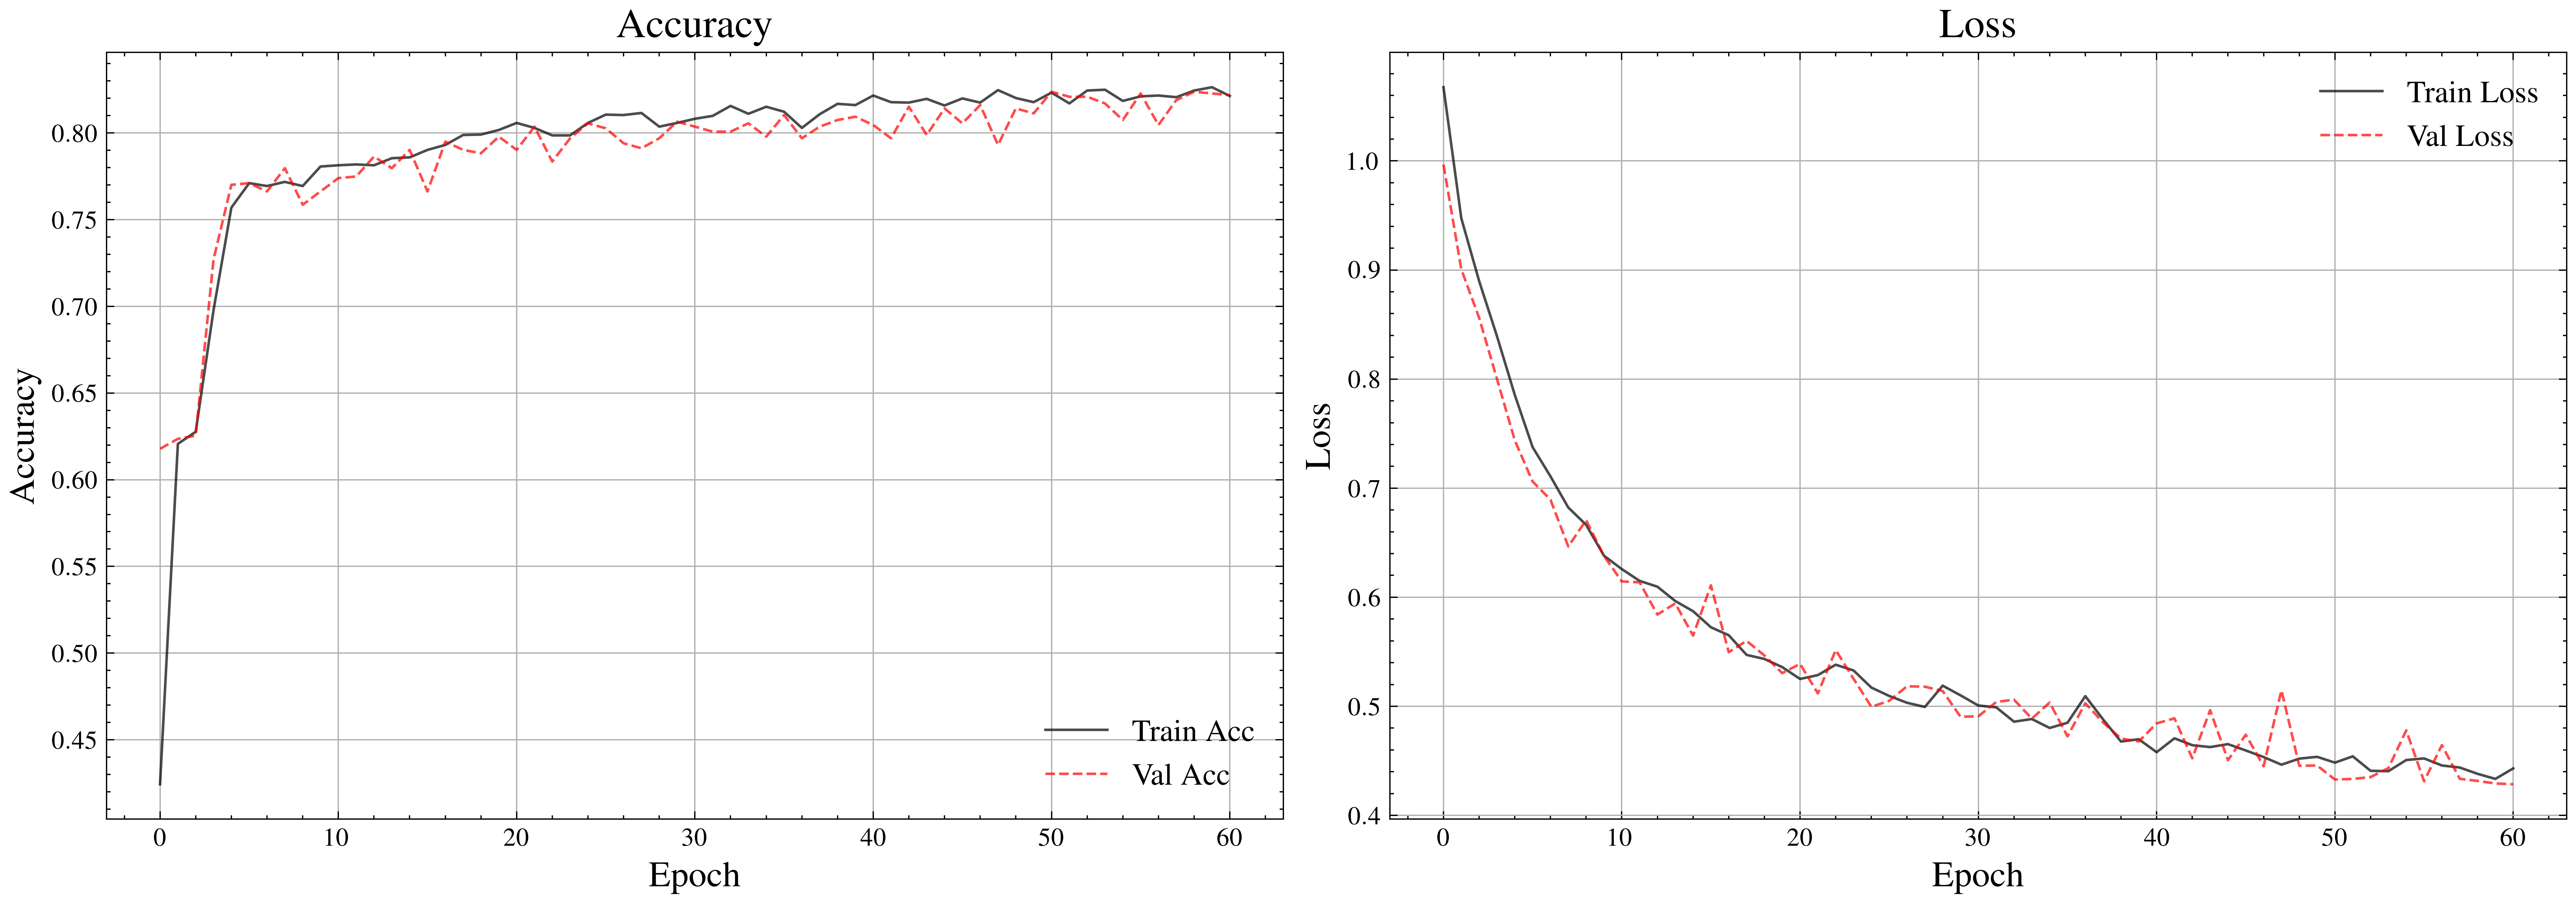

In [235]:
plot_metrics(histories)

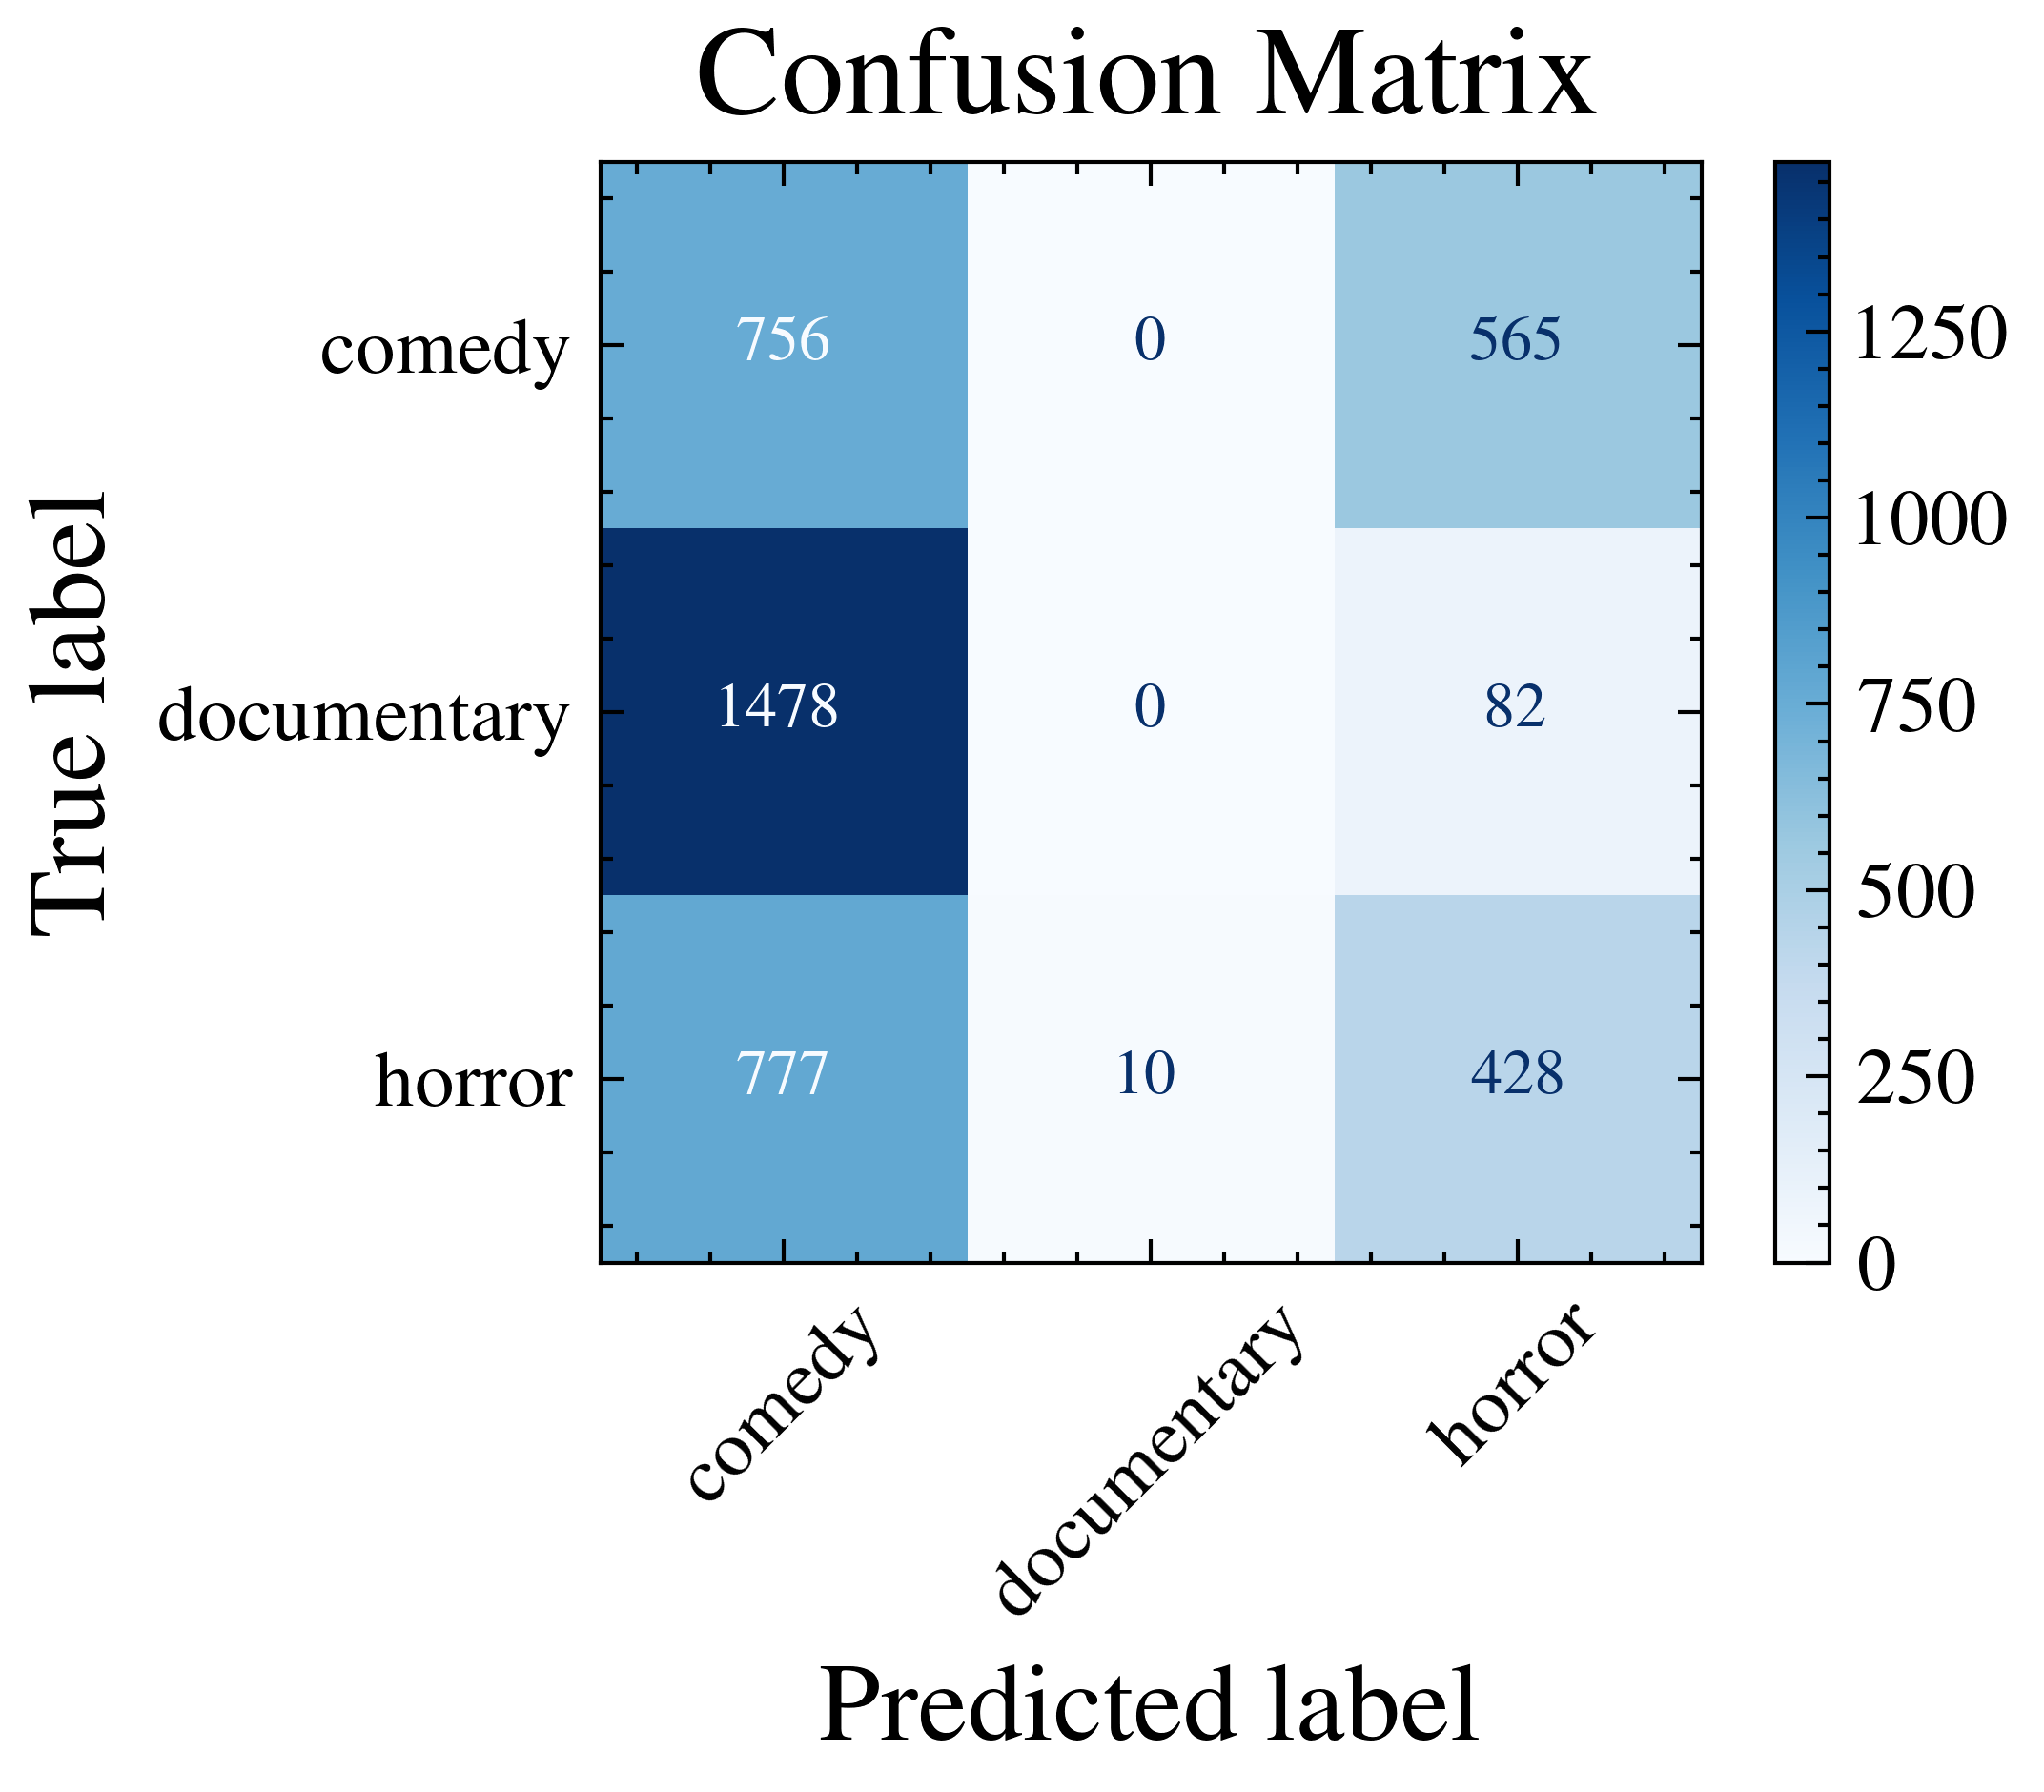

In [233]:
disp = ConfusionMatrixDisplay(confusion_matrix=cms[0], display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

### Handpicked features

In [ ]:
histories, cms, reports, accuracies = run_experiment(train_X_original, train_y_original, test_X_original, test_y_original, window_size=20, epochs=100, batch_size=32, repeats=1, units=16, dropout_rate=0.3, dense_units=10, verbose=2, learning_rate=0.0005)


--- Run #1 ---
Epoch 1/100
131/131 - 81s - 619ms/step - accuracy: 0.3308 - loss: 1.1010 - val_accuracy: 0.4140 - val_loss: 1.0908
Epoch 2/100
131/131 - 3s - 26ms/step - accuracy: 0.4092 - loss: 1.0803 - val_accuracy: 0.4140 - val_loss: 1.0544
Epoch 3/100
131/131 - 3s - 26ms/step - accuracy: 0.4760 - loss: 1.0027 - val_accuracy: 0.5813 - val_loss: 0.9347
Epoch 4/100
131/131 - 3s - 26ms/step - accuracy: 0.6130 - loss: 0.9126 - val_accuracy: 0.6472 - val_loss: 0.8617
Epoch 5/100
131/131 - 3s - 25ms/step - accuracy: 0.6451 - loss: 0.8531 - val_accuracy: 0.6472 - val_loss: 0.8120
Epoch 6/100
131/131 - 3s - 26ms/step - accuracy: 0.6443 - loss: 0.8104 - val_accuracy: 0.6424 - val_loss: 0.7744
Epoch 7/100
131/131 - 4s - 27ms/step - accuracy: 0.6501 - loss: 0.7757 - val_accuracy: 0.6434 - val_loss: 0.7506
Epoch 8/100
131/131 - 4s - 27ms/step - accuracy: 0.6451 - loss: 0.7584 - val_accuracy: 0.6444 - val_loss: 0.7382
Epoch 9/100
131/131 - 4s - 28ms/step - accuracy: 0.6422 - loss: 0.7443 - val_a

In [212]:
print(reports[0])

              precision    recall  f1-score   support

      comedy       0.71      0.02      0.04      1336
 documentary       0.78      0.98      0.87      1560
      horror       0.56      0.97      0.71      1211

    accuracy                           0.66      4107
   macro avg       0.68      0.66      0.54      4107
weighted avg       0.69      0.66      0.55      4107



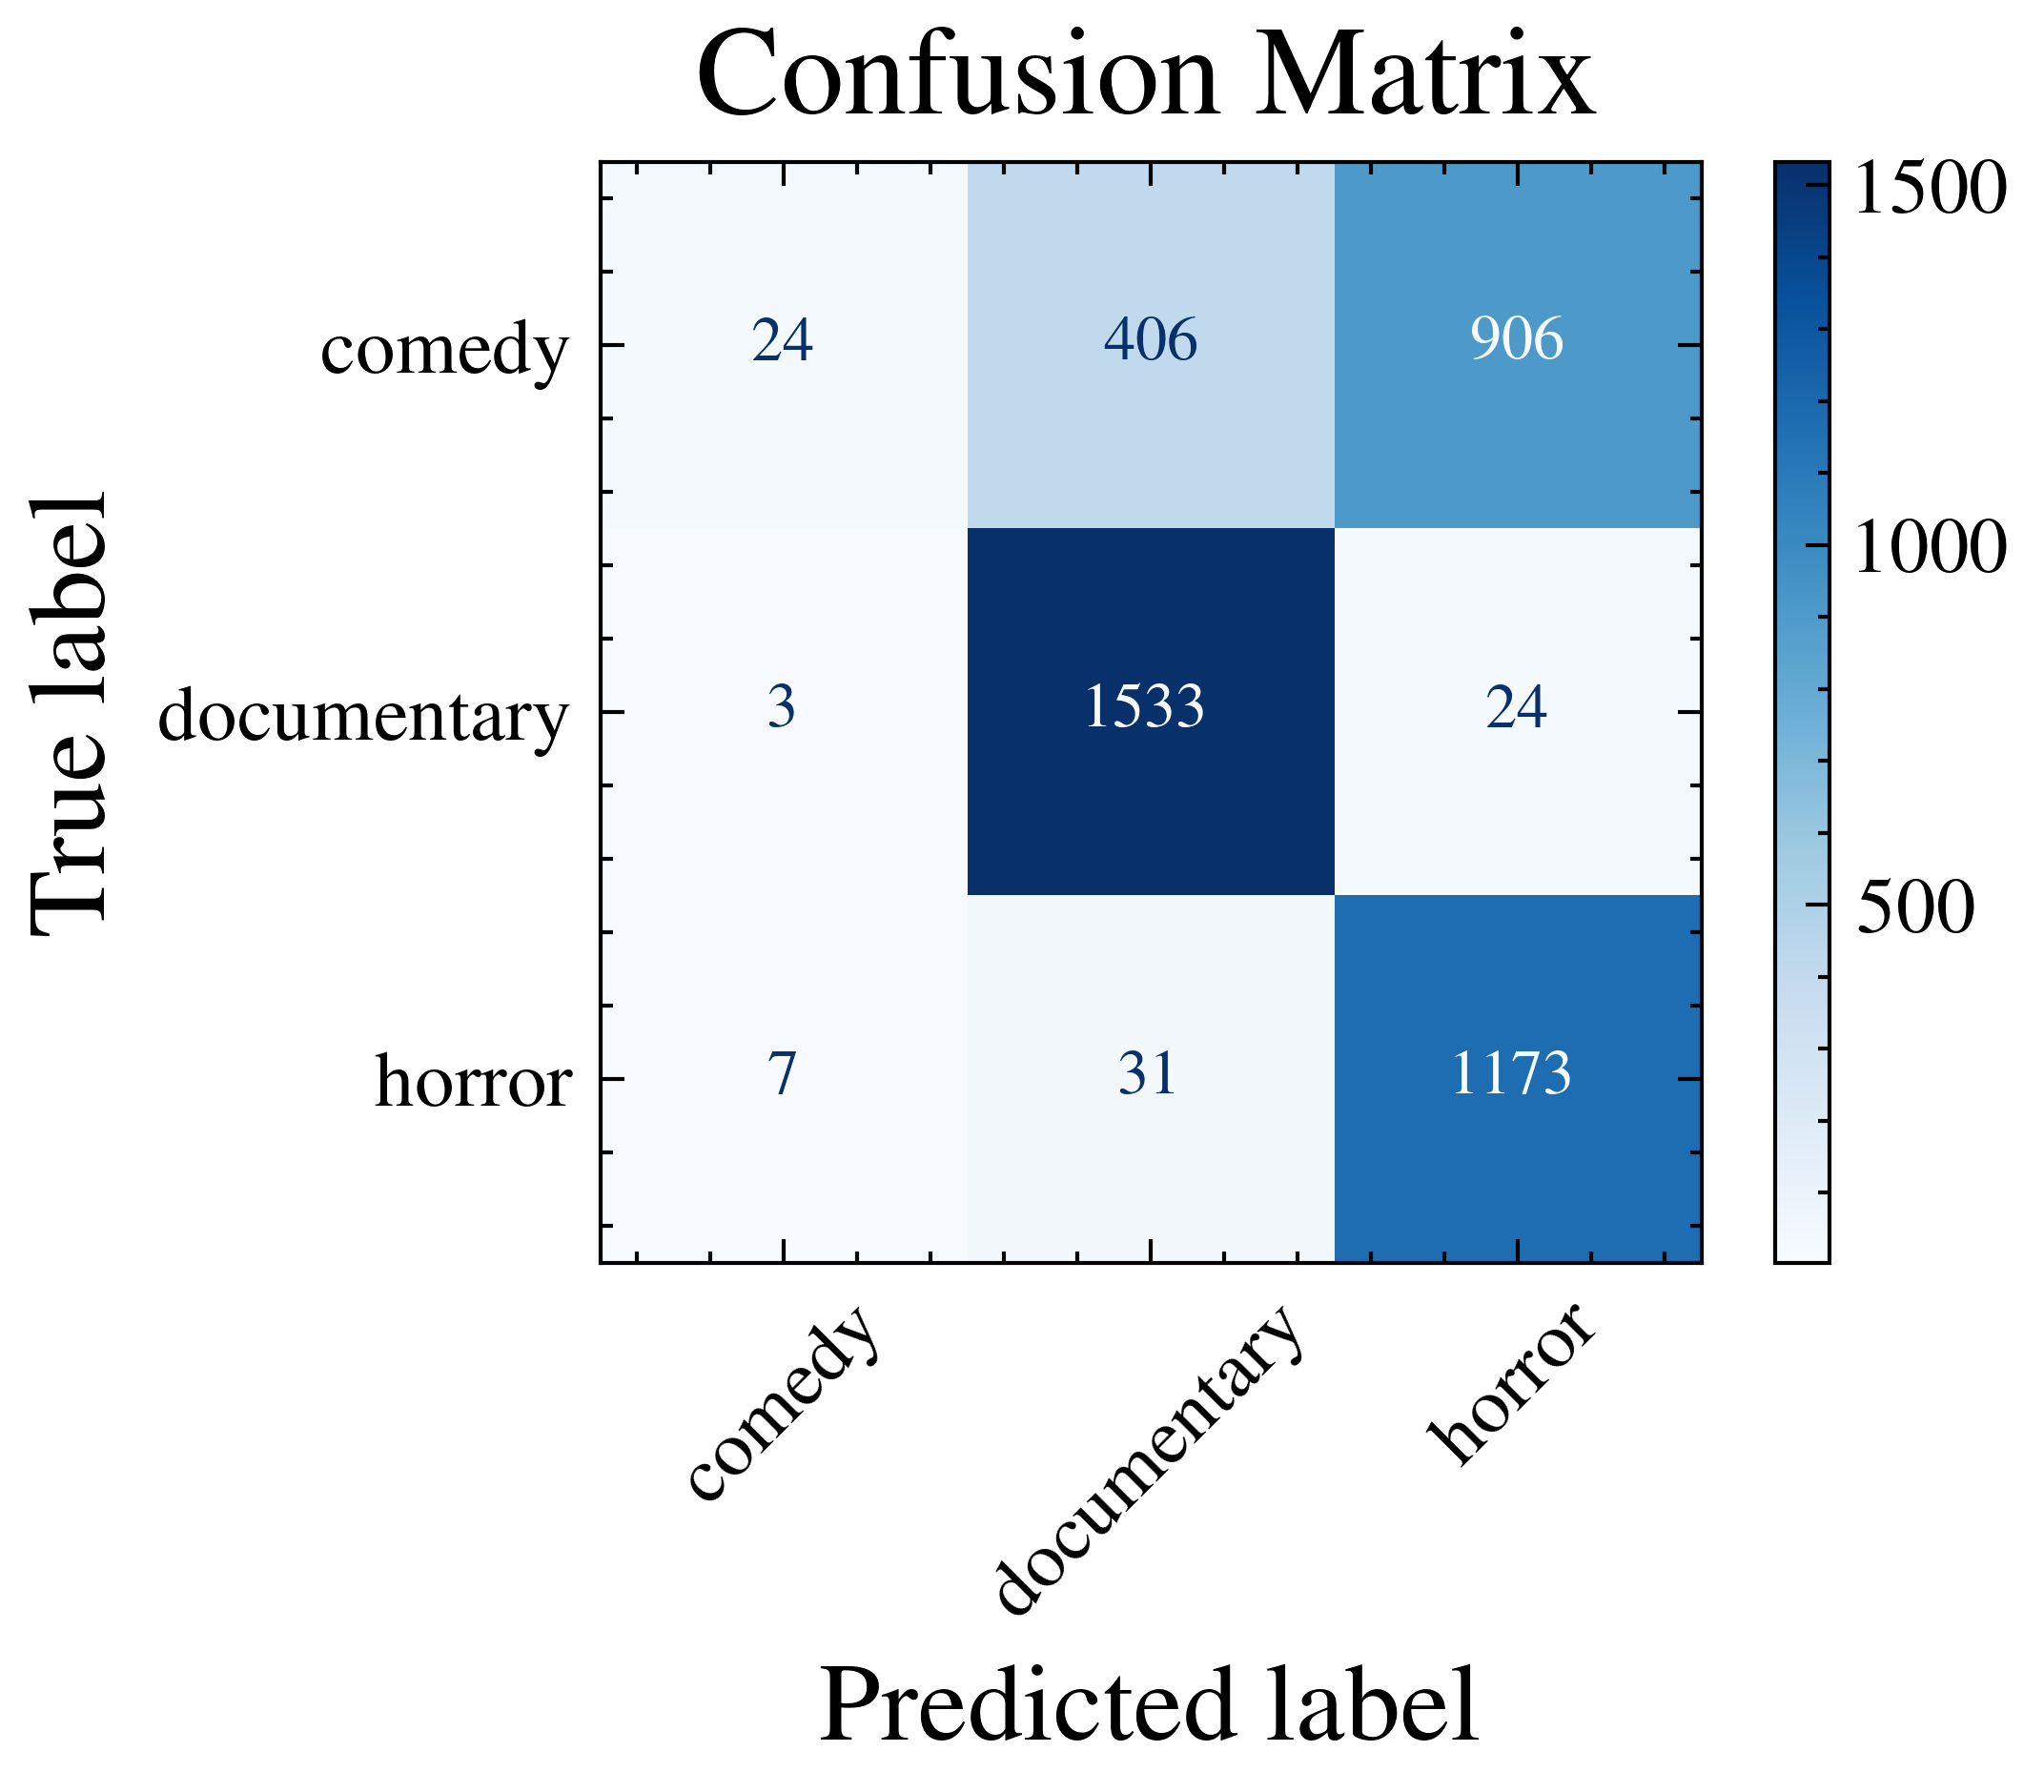

In [213]:
disp = ConfusionMatrixDisplay(confusion_matrix=cms[0], display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

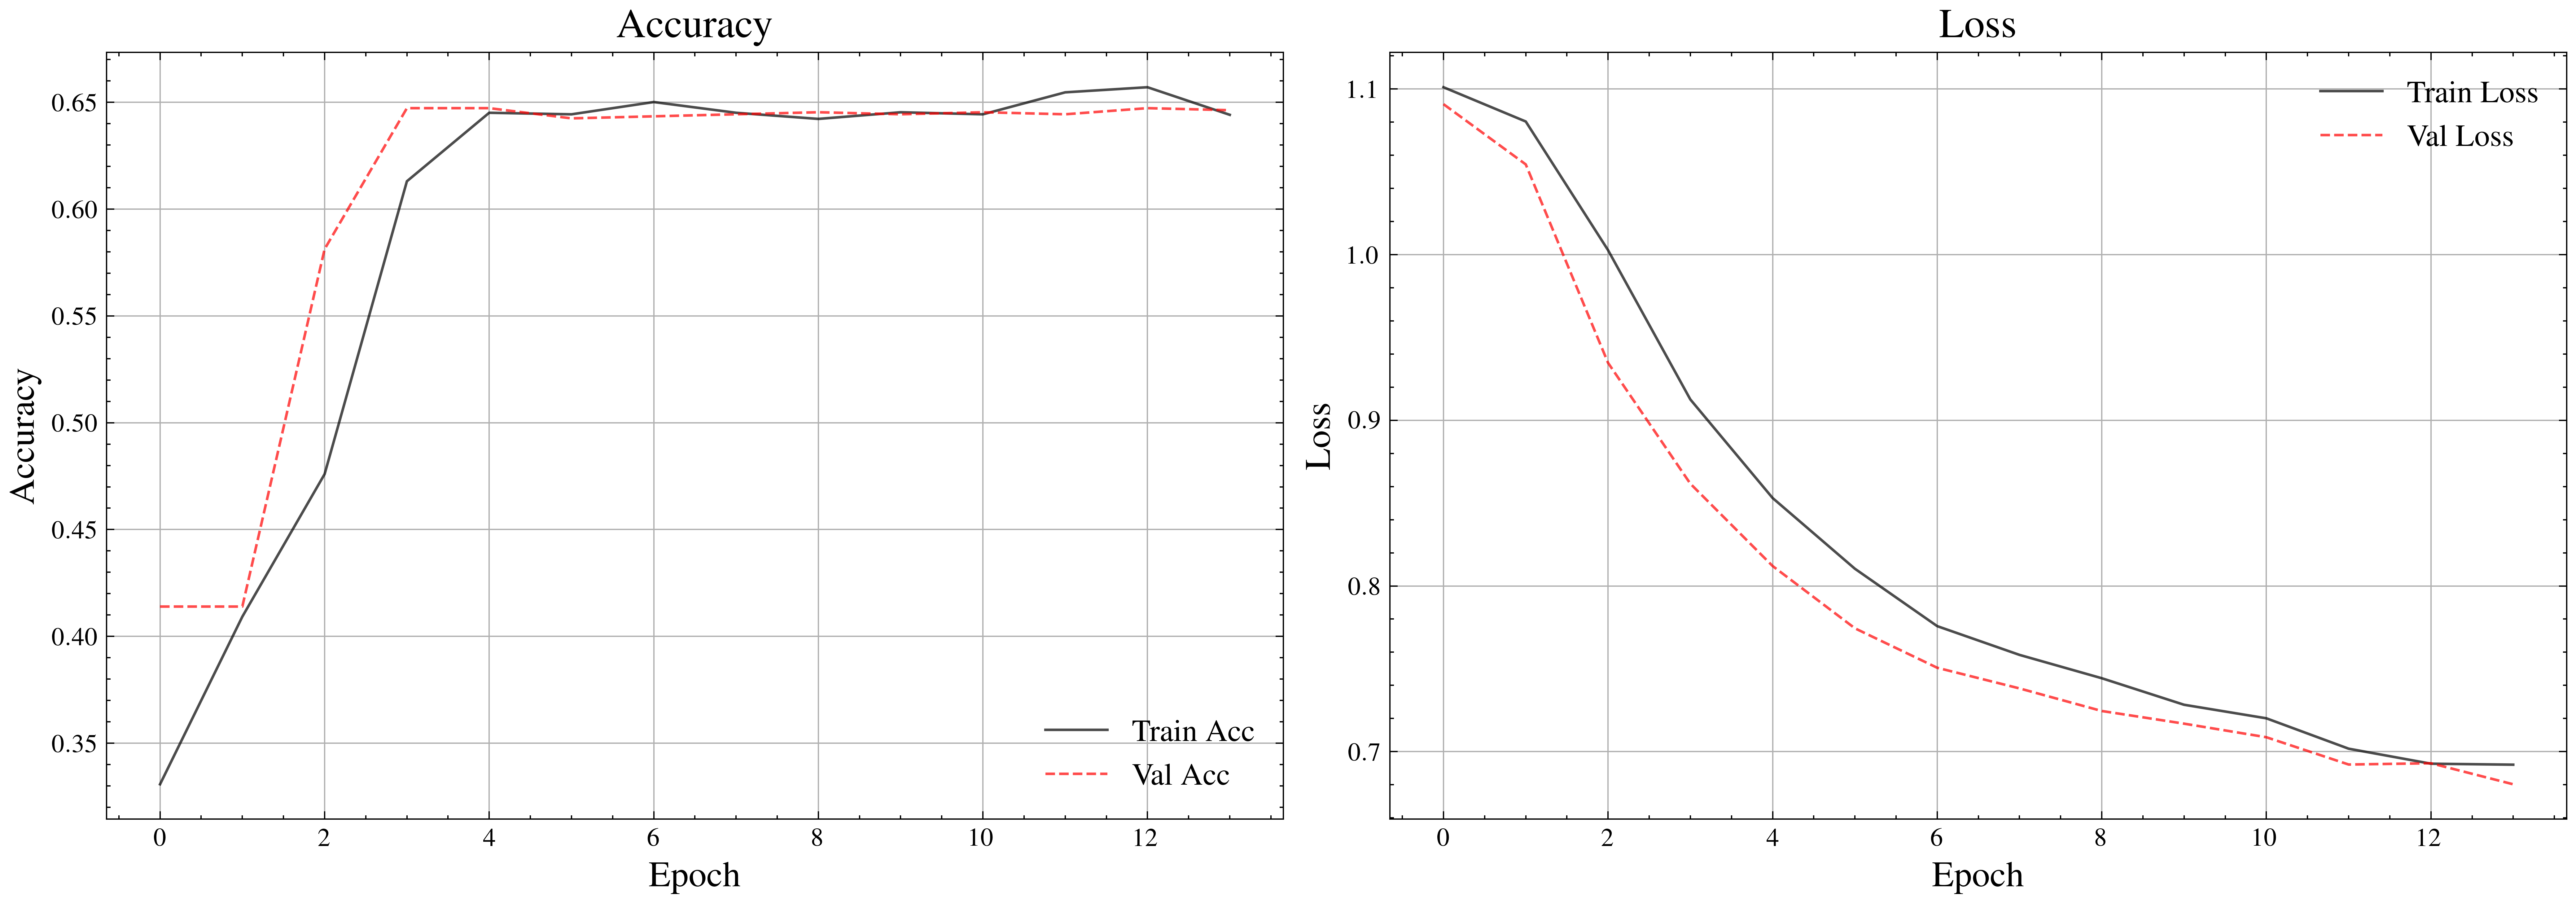

In [214]:
plot_metrics(histories)